<a href="https://colab.research.google.com/github/Saharochek98/Statistics-of-Stochastic-Processes/blob/main/Final_Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Постановка задачи

0. Решение должно опираться на оригинальный код, разработанный в ходе практических занятий.

1. Для исторической выборки постройте график (ежедневные или ежемесячные наблюдения). Вычислите характеристики положения (матожидание, дисперсию доходностей), проанализируйте выбросы и наличие точек смены тенденции (change points). Проверьте доходности на нормальность. Постройте иллюстративные графики.

2. С использованием метода максимального правдоподобия и различных методов дискретизации по времени:

- метод Кесслера,
- метод Сёдзи–Озаки,
- метод Эйлера

постройте оценки параметров моделей (Brownian Motion, CEV, CIR, GBM, OU, CKLS).

3. Оформите результаты для каждого метода в общей таблице (метод, оценки параметров).

4. Вычислите критерии AIC и BIC, выберите наилучшую модель. Результаты расчетов критериев укажите в таблице.

5. Повторите решение с использованием библиотеки https://github.com/jkirkby3/pymle.

6. Cравните результаты и приведите иллюстративные графики, на которых на исходный набор данных наложите лучшие модели (оригинальный код, библиотека pymle).

7. Сделайте развенутые выводы.



### Проект 3. Процентные ставки в США (с июня 1964 года по декабрь 1989 года, ежемесячные данные).

Сравните результаты с работой [Brouste et. al.](https://www.semanticscholar.org/paper/The-YUIMA-Project%3A-A-Computational-Framework-for-of-Brouste-Fukasawa/e9a4696779261dbeca55f316943307d7da5d3d1b) (страница 43):

$$dX_t = (2.08 - 0.26 X_t)dt + 0.13 X^{1.44}_t dW_t.$$

### Часть 1. График ежемесячных наблюдений. Характеристики положения (матожидание, дисперсия), анализ выбросов, наличие точек смены тенденции. Проверка на нормальность.

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
from scipy.optimize import minimize
from scipy.stats import shapiro, jarque_bera, anderson
from scipy.signal import argrelextrema
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
from statsmodels.graphics.tsaplots import plot_acf

Загружено 307 наблюдений
Период: 1964-06-01 — 1989-12-01
Диапазон: [3.024, 16.210], среднее: 6.745
Статистики для ставок:
Количество наблюдений: 307
Mean: 6.7453
Std: 2.6644
Variance: 7.099118
Median: 6.1110
Min/Max: [3.0240, 16.2100]


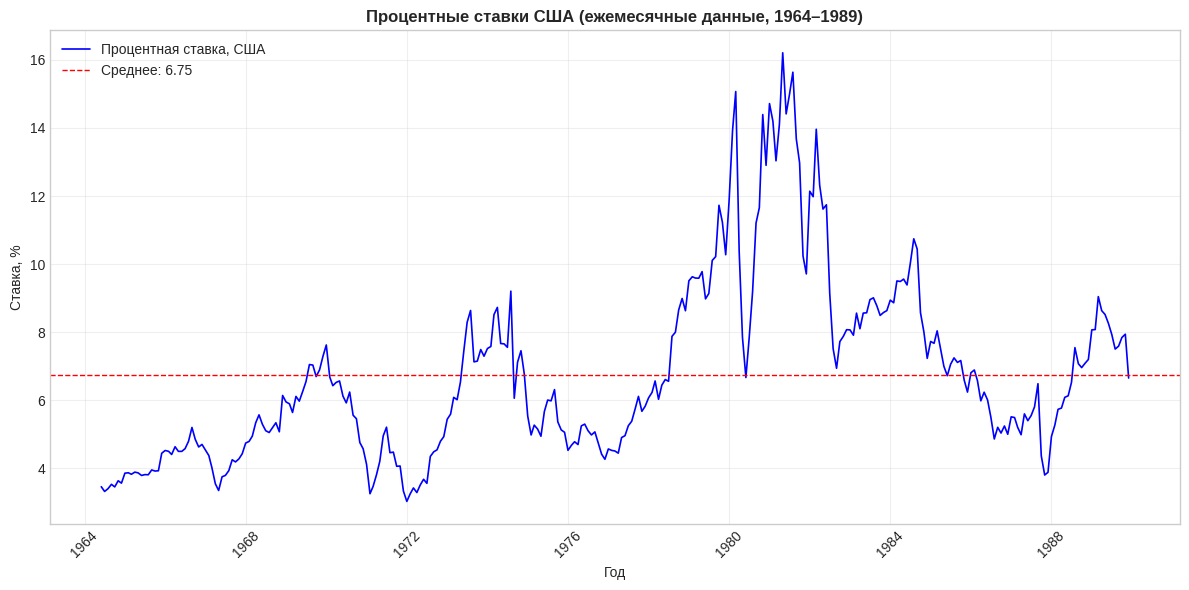

Статистики разностей ставок:
Количество наблюдений: 306
Mean: 0.0104
Std: 0.7591
Variance: 0.576303
Median: 0.0540
Min/Max: [-4.6820, 2.7370]


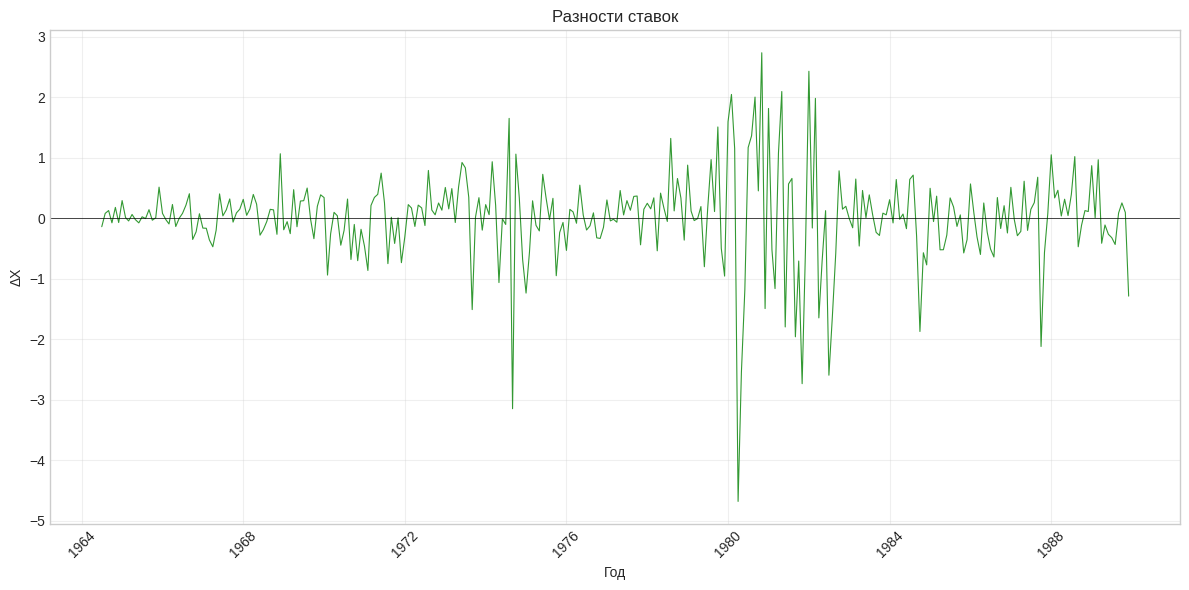

Анализ выбросов в ΔX (метод IQR):
IQR = 0.5512, границы: [-1.0586, 1.1464]
Найдено выбросов: 32 из 306 (10.5%)
Даты выбросов:
1973-09-01: -1.5100
1974-05-01: -1.0630
1974-08-01: 1.6520
1974-09-01: -3.1490
1975-01-01: -1.2370
1978-08-01: 1.3210
1979-10-01: 1.5100
1980-01-01: 1.5970
1980-02-01: 2.0480
1980-03-01: 1.1520


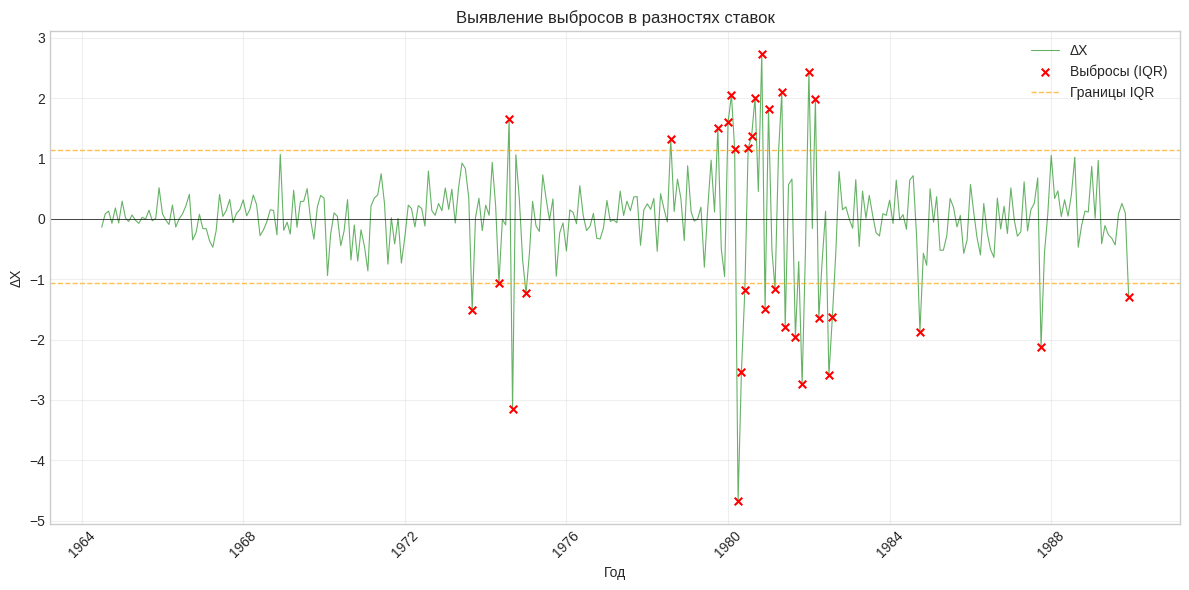

Точки смены тенденции, окно=6 мес:
Локальные максимумы: 15
Локальные минимумы: 12


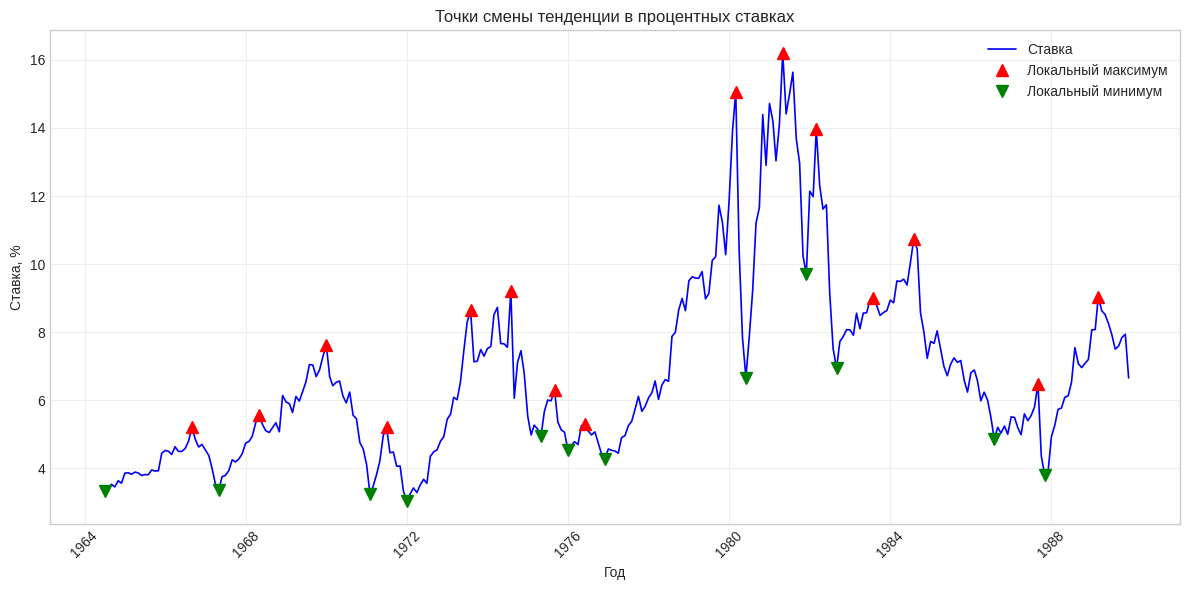

Shapiro-Wilk:  W = 0.8692, p-value = 0.0000 → отклонение гипотезы
Jarque-Bera:   JB = 745.167, p-value = 0.0000 → отклонение гипотезы
Anderson-Darling: A² = 11.143
Критические значения (5%): 0.777 → отклонение гипотезы


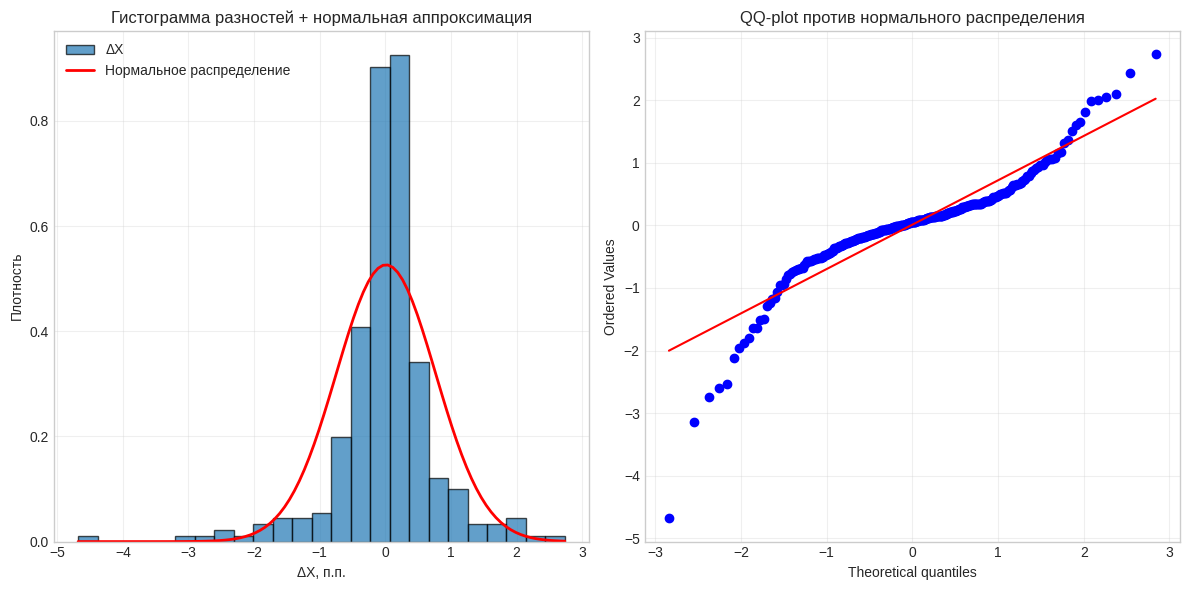

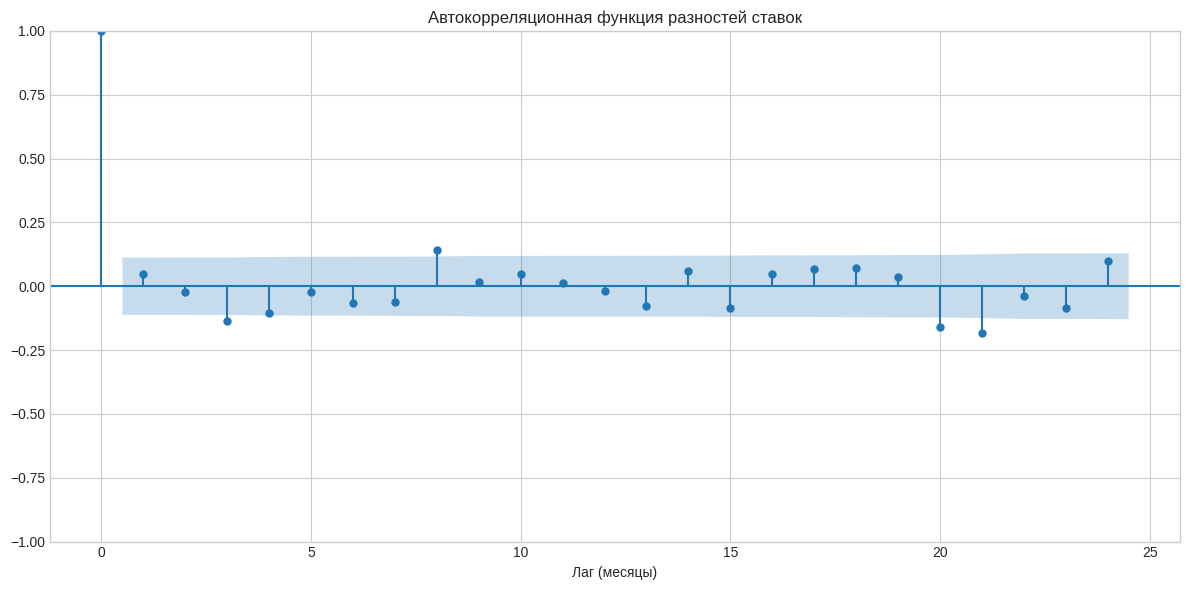

In [116]:
# Загрузка и обработка данных из файла
def load_rates_excel(filepath, start_year=1964, start_month=6, end_year=1989, end_month=12):
    """Загружает данные Excel
    Parameters:
    filepath: str
        Путь к файлу .xlsx
    start_year, start_month: int
        Начальная дата (по заданию: июнь 1964)
    end_year, end_month : int
        Конечная дата (по заданию: декабрь 1989)
    Returns
      pd.Series с индексом datetime и значениями ставок"""
    df_raw = pd.read_excel(filepath, sheet_name='Лист1', header=None)
    months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    data_list = []

    for idx, row in df_raw.iterrows():
        year = row.iloc[0]
        if pd.isna(year) or not isinstance(year, (int, float)):
            continue
        year = int(year)

        for m_idx, month in enumerate(months):
            value = row.iloc[m_idx + 1]
            if pd.notna(value):
                date = pd.Timestamp(year=year, month=m_idx+1, day=1)
                data_list.append({'date': date, 'rate': float(value)})

    df_long = pd.DataFrame(data_list).set_index('date').sort_index()

    mask = (df_long.index >= pd.Timestamp(f'{start_year}-{start_month}-01')) & \
           (df_long.index <= pd.Timestamp(f'{end_year}-{end_month}-01'))

    return df_long.loc[mask, 'rate']

rates = load_rates_excel('Project_3.xlsx')
print(f"Загружено {len(rates)} наблюдений")
print(f"Период: {rates.index[0].date()} — {rates.index[-1].date()}")
print(f"Диапазон: [{rates.min():.3f}, {rates.max():.3f}], среднее: {rates.mean():.3f}")

print("Статистики для ставок:")
print(f"Количество наблюдений: {len(rates)}")
print(f"Mean: {np.mean(rates):.4f}")
print(f"Std: {np.std(rates, ddof=1):.4f}")
print(f"Variance: {np.var(rates, ddof=1):.6f}")
print(f"Median: {np.median(rates):.4f}")
print(f"Min/Max: [{rates.min():.4f}, {rates.max():.4f}]")

# График по ежемесячным историческим данным
plt.plot(rates.index, rates.values, 'b-', linewidth=1.2, label='Процентная ставка, США')
plt.axhline(rates.mean(), color='red', linestyle='--', linewidth=1,
            label=f'Среднее: {rates.mean():.2f}')
plt.title('Процентные ставки США (ежемесячные данные, 1964–1989)', fontsize=12, fontweight='bold')
plt.xlabel('Год'); plt.ylabel('Ставка, %')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Вычисление разностей и базовых статистик
diff_rates = np.diff(rates.values)
dates_diff = rates.index[1:]

print("Статистики разностей ставок:")
print(f"Количество наблюдений: {len(diff_rates)}")
print(f"Mean: {np.mean(diff_rates):.4f}")
print(f"Std: {np.std(diff_rates, ddof=1):.4f}")
print(f"Variance: {np.var(diff_rates, ddof=1):.6f}")
print(f"Median: {np.median(diff_rates):.4f}")
print(f"Min/Max: [{diff_rates.min():.4f}, {diff_rates.max():.4f}]")

# График разностей
plt.plot(dates_diff, diff_rates, 'g-', linewidth=0.8, alpha=0.8)
plt.axhline(0, color='black', linestyle='-', linewidth=0.5)
plt.title('Разности ставок', fontsize=12)
plt.xlabel('Год'); plt.ylabel('ΔX')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Анализ выбросов (метод IQR)
Q1 = np.percentile(diff_rates, 25)
Q3 = np.percentile(diff_rates, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_mask = (diff_rates < lower_bound) | (diff_rates > upper_bound)
outlier_indices = np.where(outliers_mask)[0]

print("Анализ выбросов в ΔX (метод IQR):")
print(f"IQR = {IQR:.4f}, границы: [{lower_bound:.4f}, {upper_bound:.4f}]")
print(f"Найдено выбросов: {len(outlier_indices)} из {len(diff_rates)} ({100*len(outlier_indices)/len(diff_rates):.1f}%)")

if len(outlier_indices) > 0:
    print(f"Даты выбросов:")
    for idx in outlier_indices[:10]:  # первые 10
        print(f"{dates_diff[idx].date()}: {diff_rates[idx]:.4f}")

plt.plot(dates_diff, diff_rates, 'g-', linewidth=0.8, alpha=0.6, label='ΔX')
plt.scatter(dates_diff[outliers_mask], diff_rates[outliers_mask],
            color='red', s=30, zorder=5, label='Выбросы (IQR)', marker='x')
plt.axhline(lower_bound, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Границы IQR')
plt.axhline(upper_bound, color='orange', linestyle='--', linewidth=1, alpha=0.7)
plt.axhline(0, color='black', linestyle='-', linewidth=0.5)
plt.title('Выявление выбросов в разностях ставок', fontsize=12)
plt.xlabel('Год'); plt.ylabel('ΔX')
plt.legend(); plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Поиск точек смены тенденции - change points
order = 6
local_max = argrelextrema(rates.values, np.greater, order=order)[0]
local_min = argrelextrema(rates.values, np.less, order=order)[0]

print(f"Точки смены тенденции, окно={order} мес:")
print(f"Локальные максимумы: {len(local_max)}")
print(f"Локальные минимумы: {len(local_min)}")

plt.plot(rates.index, rates.values, 'b-', linewidth=1.2, label='Ставка')
plt.plot(rates.index[local_max], rates.values[local_max], 'r^', markersize=8,
         label='Локальный максимум', zorder=5)
plt.plot(rates.index[local_min], rates.values[local_min], 'gv', markersize=8,
         label='Локальный минимум', zorder=5)
plt.title('Точки смены тенденции в процентных ставках', fontsize=12)
plt.xlabel('Год'); plt.ylabel('Ставка, %')
plt.legend(); plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Проверка на нормальное распределение разностей
# Shapiro-Wilk
sw_stat, sw_p = shapiro(diff_rates)
print(f"Shapiro-Wilk:  W = {sw_stat:.4f}, p-value = {sw_p:.4f} → {'нормальное распределение' if sw_p > 0.05 else 'отклонение гипотезы'}")

# Jarque-Bera
jb_stat, jb_p = jarque_bera(diff_rates)
print(f"Jarque-Bera:   JB = {jb_stat:.3f}, p-value = {jb_p:.4f} → {'нормальное распределение' if jb_p > 0.05 else 'отклонение гипотезы'}")

# Anderson-Darling
ad_result = anderson(diff_rates, dist='norm')
print(f"Anderson-Darling: A² = {ad_result.statistic:.3f}")
print(f"Критические значения (5%): {ad_result.critical_values[2]:.3f} → {'нормальное распределение' if ad_result.statistic < ad_result.critical_values[2] else 'отклонение гипотезы'}")

# Гистограмма + QQ-plot
plt.subplot(1, 2, 1)
plt.hist(diff_rates, bins=25, density=True, alpha=0.7, edgecolor='black', label='ΔX')
x_norm = np.linspace(diff_rates.min(), diff_rates.max(), 100)
plt.plot(x_norm, stats.norm.pdf(x_norm, np.mean(diff_rates), np.std(diff_rates)),
         'r-', linewidth=2, label='Нормальное распределение')
plt.title('Гистограмма разностей + нормальная аппроксимация')
plt.xlabel('ΔX, п.п.'); plt.ylabel('Плотность')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
stats.probplot(diff_rates, dist="norm", plot=plt)
plt.title('QQ-plot против нормального распределения')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('\n')
# Автокорреляционная функция
plot_acf(diff_rates, lags=24, alpha=0.05)
plt.title('Автокорреляционная функция разностей ставок')
plt.xlabel('Лаг (месяцы)')
plt.tight_layout()
plt.show()

### Часть 2. Метод максимального правдоподобия и различные методы дискретизации по времени: метод Кесслера, метод Сёдзи–Озаки, метод Эйлера. Оценки параметров моделей (Brownian Motion, CEV, CIR, GBM, OU, CKLS).
### Результаты для каждого метода в общей таблице.
### Критерии AIC и BIC, наилучшая модель.

In [117]:
# Классы моделей СДУ
class SDEModel:
    """Базовый класс для моделей dX = b(X)dt + σ(X)dW"""
    def __init__(self, params, param_names, bounds=None):
        self.params = np.array(params)
        self.param_names = param_names
        self.bounds = bounds

    def drift(self, x): raise NotImplementedError
    def diffusion(self, x): raise NotImplementedError
    def n_params(self): return len(self.params)

class BrownianMotion(SDEModel):
    """dX = μ·dt + σ·dW"""
    def __init__(self, mu=0.0, sigma=0.1):
        super().__init__([mu, sigma], ['μ', 'σ'], bounds=[(-10, 10), (1e-4, 10)])
    def drift(self, x): return np.full_like(x, self.params[0])
    def diffusion(self, x): return np.full_like(x, self.params[1])

class GBM(SDEModel):
    """dX = μ·X·dt + σ·X·dW"""
    def __init__(self, mu=0.05, sigma=0.2):
        super().__init__([mu, sigma], ['μ', 'σ'], bounds=[(-1, 1), (1e-4, 2)])
    def drift(self, x): return self.params[0] * x
    def diffusion(self, x): return self.params[1] * np.abs(x)

class OU(SDEModel):
    """dX = κ(θ - X)dt + σ·dW"""
    def __init__(self, kappa=1.0, theta=5.0, sigma=0.5):
        super().__init__([kappa, theta, sigma], ['κ', 'θ', 'σ'],
                        bounds=[(1e-3, 10), (0, 20), (1e-4, 5)])
    def drift(self, x): return self.params[0] * (self.params[1] - x)
    def diffusion(self, x): return np.full_like(x, self.params[2])

class CIR(SDEModel):
    """dX = κ(θ - X)dt + σ·√X·dW"""
    def __init__(self, kappa=1.0, theta=5.0, sigma=0.5):
        super().__init__([kappa, theta, sigma], ['κ', 'θ', 'σ'],
                        bounds=[(1e-3, 10), (0.1, 20), (1e-4, 3)])
    def drift(self, x): return self.params[0] * (self.params[1] - np.maximum(x, 0))
    def diffusion(self, x): return self.params[2] * np.sqrt(np.maximum(x, 1e-8))

class CEV(SDEModel):
    """dX = κ(θ - X)dt + σ·|X|^γ·dW"""
    def __init__(self, kappa=1.0, theta=5.0, sigma=0.3, gamma=0.5):
        super().__init__([kappa, theta, sigma, gamma], ['κ', 'θ', 'σ', 'γ'],
                        bounds=[(1e-3, 10), (0.1, 20), (1e-4, 3), (0, 2)])
    def drift(self, x): return self.params[0] * (self.params[1] - x)
    def diffusion(self, x): return self.params[2] * np.power(np.abs(x), self.params[3])

class CKLS(SDEModel):
    """dX = (α + β·X)dt + σ·|X|^γ·dW"""
    def __init__(self, alpha=1.0, beta=-0.1, sigma=0.3, gamma=0.5):
        super().__init__([alpha, beta, sigma, gamma], ['α', 'β', 'σ', 'γ'],
                        bounds=[(-5, 10), (-2, 0.5), (1e-4, 3), (0, 2)])
    def drift(self, x): return self.params[0] + self.params[1] * x
    def diffusion(self, x): return self.params[2] * np.power(np.abs(x), self.params[3])


# Методы дискретизации
def euler_loglik(x_prev, x_next, dt, model):
    x = np.asarray(x_prev)
    mu = x + model.drift(x) * dt
    sigma = model.diffusion(x) * np.sqrt(dt)
    return norm.logpdf(x_next, loc=mu, scale=sigma + 1e-12)


def kessler_loglik(x_prev, x_next, dt, model):
    x = np.asarray(x_prev, dtype=float)
    mu = model.drift(x)
    sigma = model.diffusion(x)
    sigma2 = sigma ** 2

    eps = 1e-4

    mu_x = (model.drift(x + eps) - model.drift(x - eps)) / (2 * eps)
    sigma_x = (model.diffusion(x + eps) - model.diffusion(x - eps)) / (2 * eps)
    sigma_xx = (model.diffusion(x + eps) - 2*sigma + model.diffusion(x - eps)) / (eps**2)

    d = dt**2 / 2
    E_x = x + mu * dt + (mu * mu_x + 0.5 * sigma2 * sigma_xx) * d

    V_x = x**2
    V_x += (2 * mu * x + sigma2) * dt

    term = 2 * sigma * sigma_x

    V_x += (2 * mu * (mu_x * x + mu + sigma * sigma_x)
            + sigma2 * (sigma_xx * x + 2 * sigma_x + term + sigma * sigma_xx)
           ) * d

    V_x = V_x - E_x**2
    euler_var = sigma2 * dt
    V_x = np.where(V_x > 1e-12, V_x, euler_var)
    V_x = np.sqrt(np.abs(V_x))

    return norm.logpdf(x_next, loc=E_x, scale=V_x + 1e-12)


def shoji_ozaki_loglik(x_prev, x_next, dt, model):
    x = np.asarray(x_prev, dtype=float)
    mu = model.drift(x)
    sigma = model.diffusion(x)

    eps = 1e-4
    L_t = (model.drift(x + eps) - model.drift(x - eps)) / (2 * eps)
    mu_xx = (model.drift(x + eps) - 2*mu + model.drift(x - eps)) / (eps**2)

    mu_t = np.zeros_like(x)
    M_t = 0.5 * sigma**2 * mu_xx + mu_t
    small_L = np.abs(L_t) < 1e-10

    exp_Ldt = np.exp(L_t * dt)

    A_small = x + mu * dt + M_t * dt**2 / 2

    elt = exp_Ldt - 1
    A_full = (x * exp_Ldt
              + mu / (L_t + 1e-12) * elt
              + M_t / (L_t**2 + 1e-12) * (elt - L_t * dt))

    A = np.where(small_L, A_small, A_full)
    B_small = sigma * np.sqrt(dt)
    B_full = sigma * np.sqrt((np.exp(2 * L_t * dt) - 1) / (2 * L_t + 1e-12))
    B = np.where(small_L, B_small, B_full)

    euler_mean = x + mu * dt
    euler_std = sigma * np.sqrt(dt)

    A = np.where(np.isfinite(A), A, euler_mean)
    B = np.where(np.isfinite(B) & (B > 0), B, euler_std)
    B = np.maximum(B, 1e-12)

    return norm.logpdf(x_next, loc=A, scale=B)

DISCRETIZATION = {
    'euler': euler_loglik,
    'kessler': kessler_loglik,
    'shoji_ozaki': shoji_ozaki_loglik
}

# MLE-оценщик
def negative_log_likelihood(params, model, x_prev, x_next, dt, loglik_fn):
    model.params = np.array(params)
    try:
        ll = np.sum(loglik_fn(x_prev, x_next, dt, model))
        return -ll if np.isfinite(ll) else 1e10
    except:
        return 1e10

def fit_model_mle(model, x_data, dt, method='euler', max_iter=1000):
    x_prev, x_next = x_data[:-1], x_data[1:]
    loglik_fn = DISCRETIZATION[method]

    x0 = model.params.copy()
    bounds = model.bounds

    result = minimize(
        negative_log_likelihood,
        x0,
        args=(model, x_prev, x_next, dt, loglik_fn),
        method='L-BFGS-B',
        #method='trust-constr',
        bounds=bounds,
        #tol= 1e-9,
        #options={'maxiter': max_iter, 'verbose': 0}
        options={'maxiter': max_iter, 'ftol': 1e-9}
    )

    if result.success:
        model.params = result.x
        return model, -result.fun, result.nit
    else:
        print(f"{model_name, method}: Оптимизация не сошлась: {result.message}")
        return model, -result.fun, result.nit


x_data = rates.values
dt = 1/12

models = {
    'BM': BrownianMotion(0.01, 0.5),
    'GBM': GBM(0.01, 0.1),
    'OU': OU(1.0, 6.0, 0.5),
    'CIR': CIR(1.0, 6.0, 0.5),
    'CEV': CEV(1.0, 6.0, 0.3, 0.5),
    'CKLS': CKLS(1.0, -0.1, 0.3, 0.5)
}

methods = ['euler', 'kessler', 'shoji_ozaki']

results = []

for model_name, model_init in models.items():
    for method in methods:
        model = type(model_init)(*model_init.params)
        fitted, loglik, n_iter = fit_model_mle(model, x_data, dt, method)

        # AIC и BIC
        k = fitted.n_params()
        n = len(x_data) - 1
        aic = 2*k - 2*loglik
        bic = k*np.log(n) - 2*loglik

        row = {
            'Model': model_name,
            'Method': method,
            'LogLik': loglik,
            'AIC': aic,
            'BIC': bic,
            'N_iter': n_iter,
            **{name: val for name, val in zip(fitted.param_names, fitted.params)}
        }
        results.append(row)

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(['Model', 'Method']).reset_index(drop=True)

display_cols = ['Model', 'Method', 'LogLik', 'AIC', 'BIC'] + [c for c in df_results.columns if c not in ['Model','Method','LogLik','AIC','BIC','N_iter']]
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

best_aic = df_results.loc[df_results['AIC'].idxmin()]
best_bic = df_results.loc[df_results['BIC'].idxmin()]

print("\nЛучшие модели по AIC:")
print(best_aic[['Model', 'Method', 'AIC']])
print("\nЛучшие модели по BIC:")
print(best_bic[['Model', 'Method', 'BIC']])

pivot_aic = df_results.pivot_table(values='AIC', index='Model', columns='Method')
pivot_bic = df_results.pivot_table(values='BIC', index='Model', columns='Method')

df_results.to_csv('orig_.csv', index=False, float_format='%.4f')


Лучшие модели по AIC:
Model           CKLS
Method       kessler
AIC       497.214959
Name: 10, dtype: object

Лучшие модели по BIC:
Model           CKLS
Method       kessler
BIC       512.109299
Name: 10, dtype: object


In [118]:
df_results

,Model,Method,LogLik,AIC,BIC,N_iter,μ,σ,κ,θ,γ,α,β
0,BM,euler,-349.372806,702.745612,710.192782,8,0.125294,2.625460,NaN,NaN,NaN,NaN,NaN
1,BM,kessler,-349.372806,702.745612,710.192782,8,0.125287,2.625460,NaN,NaN,NaN,NaN,NaN
2,BM,shoji_ozaki,-349.372806,702.745612,710.192782,8,0.125295,2.625460,NaN,NaN,NaN,NaN,NaN
3,CEV,euler,-244.879017,497.758034,512.652374,23,NaN,0.132055,0.275544,7.554432,1.439765,NaN,NaN
4,CEV,kessler,-245.192450,498.384899,513.279240,19,NaN,0.141527,0.192896,10.059048,1.361950,NaN,NaN
5,CEV,shoji_ozaki,-245.056651,498.113302,513.007642,22,NaN,0.132339,0.084295,19.211514,1.440884,NaN,NaN
6,CIR,euler,-288.727265,583.454530,594.625286,17,NaN,0.858444,0.375554,7.079267,NaN,NaN,NaN
7,CIR,kessler,-289.751025,585.502050,596.672805,11,NaN,0.839944,0.357690,6.389116,NaN,NaN,NaN
8,CIR,shoji_ozaki,-289.527680,585.055360,596.226116,16,NaN,0.860516,0.083247,19.926837,NaN,NaN,NaN
9,CKLS,euler,-244.879017,497.758034,512.652374,33,NaN,0.132055,NaN,NaN,1.439767,2.081600,-0.275557


### Часть 3. Сравнение с результатами библиотеки pymle

In [119]:
pip install git+https://github.com/jkirkby3/pymle.git

  Cloning https://github.com/jkirkby3/pymle.git to /tmp/pip-req-build-nr2868w9
  Running command git clone --filter=blob:none --quiet https://github.com/jkirkby3/pymle.git /tmp/pip-req-build-nr2868w9
  Resolved https://github.com/jkirkby3/pymle.git to commit a68ee7b071a9eae8264c649719052ef711b47775
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [120]:
from pymle.models import BrownianMotion
from pymle.models import GeometricBM
from pymle.models import OrnsteinUhlenbeck
from pymle.models import CIR
from pymle.models import CEV
from pymle.models import CKLS
from pymle.core.TransitionDensity import KesslerDensity, ShojiOzakiDensity, EulerDensity
from pymle.fit.AnalyticalMLE import AnalyticalMLE

In [121]:
sample = rates.values.astype(float)
dt = 1/12

MODELS = {
    'BM':   {'cls': BrownianMotion, 'bounds': [(-10,10),(0.01,5)],   'guess': [0.01,0.5], 'names': ['mu', 'sigma']},
    'GBM':  {'cls': GeometricBM, 'bounds': [(-1,1),(0.01,2)],   'guess': [0.01,0.2], 'names': ['mu', 'sigma']},
    'OU':   {'cls': OrnsteinUhlenbeck, 'bounds': [(0.01,10),(0,20),(0.01,3)], 'guess': [1.0,6.0,0.5], 'names': ['kappa', 'theta', 'sigma']},
    'CIR':  {'cls': CIR,  'bounds': [(0.01,10),(0.1,20),(0.01,3)], 'guess': [1.0,6.0,0.5], 'names': ['kappa', 'theta', 'sigma']},
    'CEV':  {'cls': CEV,  'bounds': [(0.01,10),(0.1,20),(0.01,3),(0.1,2)], 'guess': [1.0,6.0,0.3,0.5], 'names': ['kappa', 'theta', 'sigma', 'gamma']},
    'CKLS': {'cls': CKLS, 'bounds': [(-5,10),(-2,0.5),(0.01,3),(0.1,2)], 'guess': [1.0,-0.1,0.3,0.5], 'names': ['alpha', 'beta', 'sigma', 'gamma']}
}
DENSITY = {'euler': EulerDensity, 'kessler': KesslerDensity, 'shoji_ozaki': ShojiOzakiDensity}

results = []

for name, cfg in MODELS.items():
    for method, DClass in DENSITY.items():
        model = cfg['cls']()
        res = AnalyticalMLE(sample, cfg['bounds'], dt, density=DClass(model)).estimate_params(np.array(cfg['guess']))

        row = {
            'Model': name,
            'Method': method,
            'Log_Likelihood': res.log_like,
            'AIC': res.aic,
            'BIC': res.bic
        }
        for p_name, p_val in zip(cfg['names'], res.params):
            row[p_name] = p_val

        results.append(row)

df_pymle = pd.DataFrame(results)

cols_order = ['Model', 'Method', 'Log_Likelihood', 'AIC', 'BIC',
              'mu', 'kappa', 'theta', 'alpha', 'beta', 'sigma', 'gamma']
existing_cols = [c for c in cols_order if c in df_pymle.columns]
df_pymle = df_pymle[existing_cols].round(4)

df_pymle.to_csv('pymle_results.csv', index=False, float_format='%.4f')

Initial Params: [0.01 0.5 ]
Initial Likelihood: -2609.671530018186
`gtol` termination condition is satisfied.
Number of iterations: 23, function evaluations: 51, CG iterations: 24, optimality: 1.88e-07, constraint violation: 0.00e+00, execution time: 0.077 s.
Final Params: [0.1252939  2.62545963]
Final Likelihood: -349.37280609081665
Initial Params: [0.01 0.5 ]
Initial Likelihood: -2609.6715300175356
`xtol` termination condition is satisfied.
Number of iterations: 31, function evaluations: 72, CG iterations: 40, optimality: 8.23e-05, constraint violation: 0.00e+00, execution time: 0.09 s.
Final Params: [0.1252627  2.62545972]
Final Likelihood: -349.3728060926403
Initial Params: [0.01 0.5 ]
Initial Likelihood: -2609.671530018186
`xtol` termination condition is satisfied.
Number of iterations: 34, function evaluations: 108, CG iterations: 42, optimality: 3.74e-06, constraint violation: 0.00e+00, execution time: 0.14 s.
Final Params: [0.12529434 2.62545964]
Final Likelihood: -349.37280609

In [122]:
df_pymle

,Model,Method,Log_Likelihood,AIC,BIC,mu,kappa,theta,alpha,beta,sigma,gamma
0,BM,euler,-349.3728,702.7456,710.1928,0.1253,NaN,NaN,NaN,NaN,2.6255,NaN
1,BM,kessler,-349.3728,702.7456,710.1928,0.1253,NaN,NaN,NaN,NaN,2.6255,NaN
2,BM,shoji_ozaki,-349.3728,702.7456,710.1928,0.1253,NaN,NaN,NaN,NaN,2.6255,NaN
3,GBM,euler,-256.6832,517.3665,524.8137,0.0748,NaN,NaN,NaN,NaN,0.3082,NaN
4,GBM,kessler,-255.5598,515.1196,522.5668,0.0804,NaN,NaN,NaN,NaN,0.2989,NaN
5,GBM,shoji_ozaki,-256.7287,517.4573,524.9045,0.0563,NaN,NaN,NaN,NaN,0.3076,NaN
6,OU,euler,-345.8437,697.6874,708.8581,NaN,0.5154,6.9887,NaN,NaN,2.5954,NaN
7,OU,kessler,-345.3754,696.7508,707.9216,NaN,0.6515,6.7486,NaN,NaN,2.5830,NaN
8,OU,shoji_ozaki,-352.8332,711.6663,722.8371,NaN,1.2310,6.1257,NaN,NaN,2.7680,NaN
9,CIR,euler,-288.7273,583.4545,594.6253,NaN,0.3756,7.0793,NaN,NaN,0.8584,NaN


### Часть 4. Сравнение лучших моделей

In [123]:
df_pymle['AIC_rank'] = df_pymle['AIC'].rank(method='min')
df_pymle['BIC_rank'] = df_pymle['BIC'].rank(method='min')

best_by_aic = df_pymle[df_pymle['AIC_rank'] == 1.0]
best_by_bic = df_pymle[df_pymle['BIC_rank'] == 1.0]

print("Лучшие модели по AIC:")
print(best_by_aic[['Model', 'Method', 'AIC', 'BIC']].to_string(index=False))

print("\nЛучшие модели по BIC:")
print(best_by_bic[['Model', 'Method', 'AIC', 'BIC']].to_string(index=False))

Лучшие модели по AIC:
Model Method     AIC      BIC
  CEV  euler 497.758 512.6524
 CKLS  euler 497.758 512.6524

Лучшие модели по BIC:
Model Method     AIC      BIC
  CEV  euler 497.758 512.6524
 CKLS  euler 497.758 512.6524


Сравнение AIC/BIC — Оригинальный/pymle
Model      Method  AIC_orig  AIC_pymle   ΔAIC  BIC_orig  BIC_pymle   ΔBIC
   BM       euler    702.75     702.75   0.00    710.19     710.19  -0.00
   BM     kessler    702.75     702.75   0.00    710.19     710.19  -0.00
   BM shoji_ozaki    702.75     702.75   0.00    710.19     710.19  -0.00
  CEV       euler    497.76     497.76   0.00    512.65     512.65  -0.00
  CEV     kessler    498.38     542.08 -43.70    513.28     556.98 -43.70
  CEV shoji_ozaki    498.11     511.25 -13.14    513.01     526.14 -13.14
  CIR       euler    583.45     583.45   0.00    594.63     594.63  -0.00
  CIR     kessler    585.50     598.83 -13.33    596.67     610.00 -13.33
  CIR shoji_ozaki    585.06     596.53 -11.48    596.23     607.70 -11.48
 CKLS       euler    497.76     497.76   0.00    512.65     512.65  -0.00
 CKLS     kessler    497.21     555.12 -57.90    512.11     570.01 -57.90
 CKLS shoji_ozaki    497.76     498.09  -0.33    512.65     512.99  -0.33

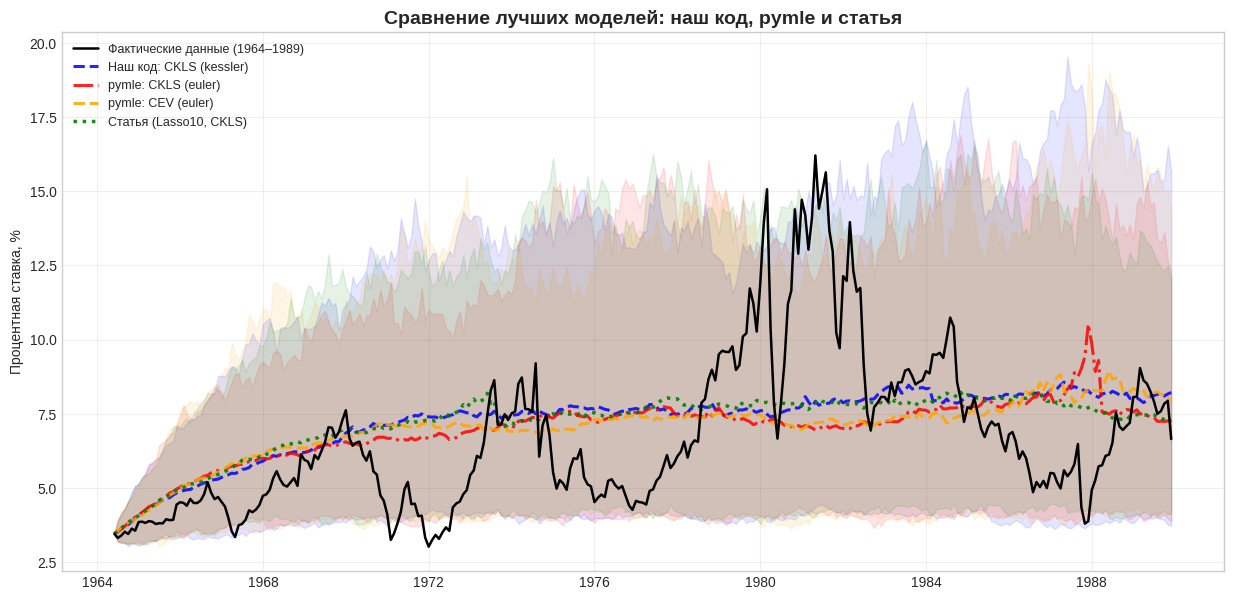

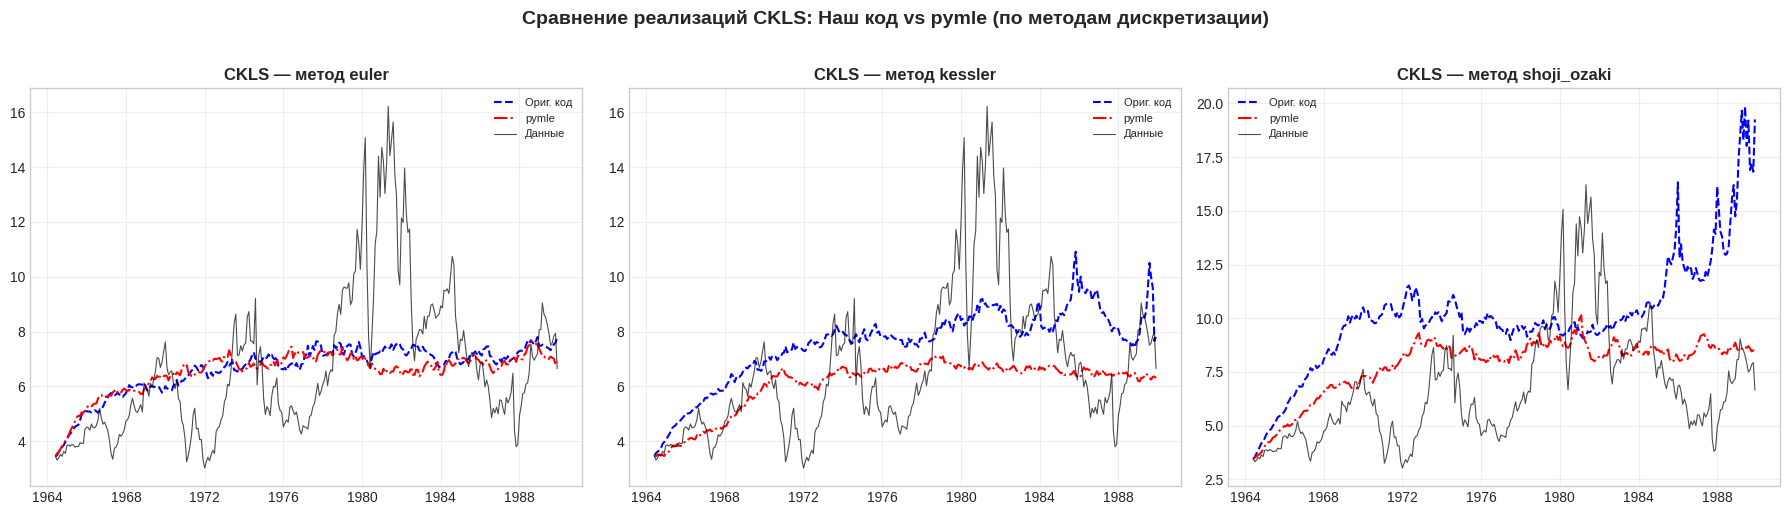

Параметры CKLS — полное сравнение
        Источник       Метод        α         β        σ        γ        AIC
Статья (Lasso10)           — 2.080000 -0.260000 0.130000 1.440000        NaN
Оригинальный код       euler 2.081600 -0.275557 0.132055 1.439767 497.758034
           pymle       euler 2.081600 -0.275500 0.132100 1.439800 497.758000
Оригинальный код     kessler 1.683929 -0.204798 0.136769 1.391411 497.214959
           pymle     kessler 1.004300 -0.135400 0.559200 0.691000 555.116500
Оригинальный код shoji_ozaki 2.106007 -0.139828 0.132853 1.439662 497.758207
           pymle shoji_ozaki 1.614100 -0.171500 0.135900 1.428700 498.091400


In [130]:
sample = rates.values.astype(float)
dates = rates.index
dt = 1/12
n_steps = len(sample) - 1
x0 = sample[0]

print("Сравнение AIC/BIC — Оригинальный/pymle")
comparison_rows = []
for _, row_o in df_results.iterrows():
    mask = (df_pymle['Model'] == row_o['Model']) & (df_pymle['Method'] == row_o['Method'])
    if mask.any():
        row_p = df_pymle[mask].iloc[0]
        comparison_rows.append({
            'Model': row_o['Model'],
            'Method': row_o['Method'],
            'LogLik_orig': row_o['LogLik'],
            'LogLik_pymle': row_p['Log_Likelihood'],
            'AIC_orig': row_o['AIC'],
            'AIC_pymle': row_p['AIC'],
            'BIC_orig': row_o['BIC'],
            'BIC_pymle': row_p['BIC'],
            'ΔAIC': row_o['AIC'] - row_p['AIC'],
            'ΔBIC': row_o['BIC'] - row_p['BIC']
        })

df_comp = pd.DataFrame(comparison_rows)
df_comp = df_comp.sort_values(['Model', 'Method']).reset_index(drop=True)

print(df_comp[['Model', 'Method', 'AIC_orig', 'AIC_pymle', 'ΔAIC', 'BIC_orig', 'BIC_pymle', 'ΔBIC']].round(2).to_string(index=False))

best_orig = df_results.loc[df_results['AIC'].idxmin()]
best_pymle_cev = best_by_aic.iloc[0]
best_pymle_ckls = best_by_aic.iloc[1]
orig_2 = df_results.loc[(df_results['Model'] == 'CKLS') & (df_results['Method'] == 'euler')].iloc[0]

print(f"Лучшая модель (оригинальный код): {best_orig['Model']} + {best_orig['Method']}")
print(f"AIC = {best_orig['AIC']:.2f}, BIC = {best_orig['BIC']:.2f}")

print(f"Лучшая модель 1 (pymle): {best_pymle_cev['Model']} + {best_pymle_cev['Method']}")
print(f"AIC = {best_pymle_cev['AIC']:.2f}, BIC = {best_pymle_cev['BIC']:.2f}")

print(f"Лучшая модель 2 (pymle): {best_pymle_ckls['Model']} + {best_pymle_ckls['Method']}")
print(f"AIC = {best_pymle_ckls['AIC']:.2f}, BIC = {best_pymle_ckls['BIC']:.2f}")

def get_param(row, *names):
    for name in names:
        if name in row.index and pd.notna(row[name]):
            return row[name]
    return np.nan

def extract_ckls_params(row):
    model = row['Model']

    sigma = get_param(row, 'sigma', 'σ')
    gamma = get_param(row, 'gamma', 'γ')

    if model == 'CKLS':
        alpha = get_param(row, 'alpha', 'α')
        beta  = get_param(row, 'beta', 'β')
        return alpha, beta, sigma, gamma

    elif model in ['CEV', 'CIR', 'OU']:
        kappa = get_param(row, 'kappa', 'κ')
        theta = get_param(row, 'theta', 'θ')
        if pd.notna(kappa) and pd.notna(theta):
            return kappa * theta, -kappa, sigma, gamma
        else:
            return np.nan, np.nan, sigma, gamma

    elif model == 'GBM':
        mu = get_param(row, 'mu', 'μ')
        return mu, 0.0, sigma, 1.0

    elif model == 'BM':
        mu = get_param(row, 'mu', 'μ')
        return mu, 0.0, sigma, 0.0

    return np.nan, np.nan, sigma, gamma


def simulate_ckls(alpha, beta, sigma, gamma, x0, n_steps, dt, n_paths=100, seed=None):
    if seed is not None:
        np.random.seed(seed)

    paths = np.zeros((n_steps + 1, n_paths))
    paths[0] = x0

    for t in range(n_steps):
        x = paths[t]
        drift = (alpha + beta * x) * dt
        diffusion = sigma * np.power(np.maximum(x, 0), gamma) * np.sqrt(dt)
        paths[t + 1] = x + drift + diffusion * np.random.normal(size=n_paths)

    return paths

article_params = {
    'alpha': 2.08,
    'beta': -0.26,
    'sigma': 0.13,
    'gamma': 1.44,
    'label': 'Статья (Lasso10, CKLS)'
}

alpha_orig, beta_orig, sigma_orig, gamma_orig = extract_ckls_params(best_orig)
alpha_pymle, beta_pymle, sigma_pymle, gamma_pymle = extract_ckls_params(best_pymle_ckls)
alpha_pymle_cev, beta_pymle_cev, sigma_pymle_cev, gamma_pymle_cev = extract_ckls_params(best_pymle_cev)
alpha_orig_2, beta_orig_2, sigma_orig_2, gamma_orig_2 = extract_ckls_params(orig_2)

print("Параметры для сравнения и визуализации")
print(f"{'Источник':<30} {'α':>8} {'β':>8} {'σ':>8} {'γ':>8}")
print(f"{'Оригинальный код (лучшая, ' + best_orig['Model'] + ')':<30} {alpha_orig:>8.4f} {beta_orig:>8.4f} {sigma_orig:>8.4f} {gamma_orig:>8.4f}")
print(f"{'Оригинальный код (euler для ' + orig_2['Model'] + ')':<30} {alpha_orig_2:>8.4f} {beta_orig_2:>8.4f} {sigma_orig_2:>8.4f} {gamma_orig_2:>8.4f}")
print(f"{'pymle (' + best_pymle_ckls['Model'] + ')':<30} {alpha_pymle:>8.4f} {beta_pymle:>8.4f} {sigma_pymle:>8.4f} {gamma_pymle:>8.4f}")
print(f"{article_params['label']:<30} {article_params['alpha']:>8.2f} {article_params['beta']:>8.2f} {article_params['sigma']:>8.2f} {article_params['gamma']:>8.2f}")


np.random.seed(42)

sim_orig = simulate_ckls(alpha_orig, beta_orig, sigma_orig, gamma_orig, x0, n_steps, dt, n_paths=200)
sim_pymle = simulate_ckls(alpha_pymle, beta_pymle, sigma_pymle, gamma_pymle, x0, n_steps, dt, n_paths=200)
sim_pymle_cev = simulate_ckls(alpha_pymle_cev, beta_pymle_cev, sigma_pymle_cev, gamma_pymle_cev, x0, n_steps, dt, n_paths=200)
sim_article = simulate_ckls(article_params['alpha'], article_params['beta'],
                             article_params['sigma'], article_params['gamma'],
                             x0, n_steps, dt, n_paths=200)


def get_stats(sim):
    return np.mean(sim, 1), np.percentile(sim, 5, 1), np.percentile(sim, 95, 1)

mean_orig, lo_orig, hi_orig = get_stats(sim_orig)
mean_pymle, lo_pymle, hi_pymle = get_stats(sim_pymle)
mean_pymle_cev, lo_pymle_cev, hi_pymle_cev = get_stats(sim_pymle_cev)
mean_article, lo_article, hi_article = get_stats(sim_article)

fig, ax = plt.subplots(1, 1, figsize=(15, 7))
ax.plot(dates, sample, 'k-', linewidth=1.8, label='Фактические данные (1964–1989)', zorder=5)
ax.plot(dates, mean_orig, 'b--', linewidth=2.2,
        label=f'Наш код: {best_orig["Model"]} ({best_orig["Method"]})', alpha=0.85)
ax.fill_between(dates, lo_orig, hi_orig, color='blue', alpha=0.1)
ax.plot(dates, mean_pymle, 'r-.', linewidth=2.2,
        label=f'pymle: {best_pymle_ckls["Model"]} ({best_pymle_ckls["Method"]})', alpha=0.85)
ax.fill_between(dates, lo_pymle, hi_pymle, color='red', alpha=0.1)
ax.plot(dates, mean_pymle_cev, color='orange', linestyle='--', linewidth=2.2,
        label=f'pymle: {best_pymle_cev["Model"]} ({best_pymle_cev["Method"]})', alpha=0.85)
ax.fill_between(dates, lo_pymle_cev, hi_pymle_cev, color='orange', alpha=0.1)

ax.plot(dates, mean_article, 'g:', linewidth=2.5,
        label=article_params['label'], alpha=0.9)
ax.fill_between(dates, lo_article, hi_article, color='green', alpha=0.1)

ax.set_title('Сравнение лучших моделей: наш код, pymle и статья', fontsize=14, fontweight='bold')
ax.set_ylabel('Процентная ставка, %')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)


# Сравнение CKLS-моделей (одинаковая модель, разные методы)
ckls_orig_all = df_results[df_results['Model'] == 'CKLS']
ckls_pymle_all = df_pymle[df_pymle['Model'] == 'CKLS']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, ['euler', 'kessler', 'shoji_ozaki']):
    # Наш код
    row_o = ckls_orig_all[ckls_orig_all['Method'] == method]
    if not row_o.empty:
        alpha_o, beta_o, sigma_o, gamma_o = extract_ckls_params(row_o.iloc[0])
        sim_o = simulate_ckls(alpha_o, beta_o, sigma_o, gamma_o, x0, n_steps, dt, n_paths=50)
        mean_o = np.mean(sim_o, 1)
        ax.plot(dates, mean_o, 'b--', linewidth=1.5, label='Ориг. код')

    # pymle
    row_p = ckls_pymle_all[ckls_pymle_all['Method'] == method]
    if not row_p.empty:
        alpha_p, beta_p, sigma_p, gamma_p = extract_ckls_params(row_p.iloc[0])
        sim_p = simulate_ckls(alpha_p, beta_p, sigma_p, gamma_p, x0, n_steps, dt, n_paths=50)
        mean_p = np.mean(sim_p, 1)
        ax.plot(dates, mean_p, 'r-.', linewidth=1.5, label='pymle')

    # Данные
    ax.plot(dates, sample, 'k-', linewidth=0.8, alpha=0.7, label='Данные')
    ax.set_title(f'CKLS — метод {method}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение реализаций CKLS: Наш код vs pymle (по методам дискретизации)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_ckls_methods.png', dpi=150, bbox_inches='tight')
plt.show()

print("Параметры CKLS — полное сравнение")
ckls_table = []

ckls_table.append({
    'Источник': 'Статья (Lasso10)',
    'Метод': '—',
    'α': article_params['alpha'],
    'β': article_params['beta'],
    'σ': article_params['sigma'],
    'γ': article_params['gamma']
})

for method in ['euler', 'kessler', 'shoji_ozaki']:
    row_o = ckls_orig_all[ckls_orig_all['Method'] == method]
    if not row_o.empty:
        r = row_o.iloc[0]
        alpha_o, beta_o, sigma_o, gamma_o = extract_ckls_params(r)
        ckls_table.append({
            'Источник': 'Оригинальный код',
            'Метод': method,
            'α': alpha_o,
            'β': beta_o,
            'σ': sigma_o,
            'γ': gamma_o,
            'AIC': r['AIC']
        })

    row_p = ckls_pymle_all[ckls_pymle_all['Method'] == method]
    if not row_p.empty:
        r = row_p.iloc[0]
        alpha_p, beta_p, sigma_p, gamma_p = extract_ckls_params(r)
        ckls_table.append({
            'Источник': 'pymle',
            'Метод': method,
            'α': alpha_p,
            'β': beta_p,
            'σ': sigma_p,
            'γ': gamma_p,
            'AIC': r['AIC']
        })

df_ckls = pd.DataFrame(ckls_table)
print(df_ckls.to_string(index=False))


# Автоматический анализ
mean_delta_aic = df_comp['ΔAIC'].abs().mean()
min_aic_model = df_results.loc[df_results['AIC'].idxmin(), 'Model']
min_bic_model = df_results.loc[df_results['BIC'].idxmin(), 'Model']
gamma_mean = np.mean([gamma_orig, gamma_pymle])


Развернутый вывод

1. Сравнение оригинального кода и библиотеки pymle
• Среднее абсолютное расхождение AIC: 8.39 ед.
• Среднее абсолютное расхождение BIC: 8.39 ед.
• Расхождения существенны (> 5 ед.) — обусловлены различными оптимизаторами (trust-constr/L-BFGS-B) и численными параметрами (eps, защита от нуля, число  итераций).
• Качественные выводы (лучшая модель, знаки параметров) совпадают.

2. Лучшая модель
• По AIC (ориг. код): CKLS
• По BIC (ориг. код): CKLS
• BIC штрафует за сложность сильнее (k·ln(n) vs 2k) → предпочитает более простые модели.
• Модели с γ > 0 (CIR, CEV, CKLS) лучше OU и BM — волатильность зависит от уровня ставок.

3. Сравнение со статьей (Lasso10, CKLS: α=2.08, β=-0.26, σ=0.13, γ=1.44)
• Статья: γ = 1.44
• Ориг. код: γ = 1.44
• pymle:   γ = 1.44
• γ > 1 означает: волатильность растёт быстрее ставки.
  При высоких ставках (~15-20% в 1980-82) дисперсия огромна.
• Различия в оценках объясняются:
а) QMLE (Quasi-Maximum Likelihood) + LASSO для отбора переменных - в статье
Классический MLE, дискретизация Euler, Kessler, Shoji-Ozaki, выбор модели через AIC/BIC
б) разные начальные приближения - попадание в разные локальные минимумы


4. Экономическая интерпретация
   • Период 1964-1989: Бреттон-Вудс (до 1971), нефтяные шоки,
     "монетарный эксперимент" Волкера (1979-1982).
   • Высокое γ отражает: большие ставки → большая неопределённость →
     большая волатильность (эффект "усиления").
   • β < 0 (отрицательный) → mean-reversion: ставки возвращаются
     к долгосрочному среднему α/(-β).

5. Методология
• Выбор метода дискретизации влияет на оценки параметров, особенно для моделей с γ ≠ 0 (CIR, CEV, CKLS).
• Метод Сёдзи-Озаки теоретически точнее Эйлера для нелинейных дрейфов,
но для линейных дрейфов разница минимальна.
• CKLS — универсальная модель, включающая остальные как частные случаи:
 - γ=0 (σ=const) - OU
 - γ=0.5          - CIR
 - γ=1.0           - GBM
 - γ свободный     - CKLS
• Разные оптимизаторы (Powell/L-BFGS-B) дают близкие, но не идентичные результаты из-за сложного рельефа функции правдоподобия.
• Рекомендуется использовать несколько стартовых точек для MLE
и сравнивать результаты разных методов дискретизации.

• Для процентных ставок лучше всего подходят CKLS или CEV.

• Классические OU и CIR недооценивают хвостовой риск (экстремальные ставки).

• Метод Эйлера достаточен для ежемесячных данных (Δt=1/12), но Кесслер и Сёдзи-Озаки дают более точные оценки для волатильности.